#### **Basket Analysis with Product Embeddings**

This notebook builds a simple **Prod2Vec** model for Instacart baskets.

The idea is simple:

- A basket is treated like a sentence.
- A product is treated like a word.
- Products that appear in similar basket contexts should get similar vectors.

At the end we will pick a few popular products and print their closest neighbours in embedding space.

In [1]:
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd

from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [2]:
DATA_DIR = Path("data")

# Products with fewer basket-line occurrences than this are removed.
MIN_PRODUCT_OCCURRENCES = 20

# Word2Vec-style subsampling threshold for very frequent products.
# Frequent products like bananas and milk are useful, but if they dominate every context
# they can make the embedding space less informative.
SUBSAMPLING_T = 1e-5

# Small embeddings are enough for a classroom example and train quickly.
VECTOR_SIZE = 64
WINDOW_SIZE = 10
EPOCHS = 5
RANDOM_SEED = 42

# Set to an integer, for example 200_000, if you want a faster demo on a smaller sample.
MAX_BASKETS = None

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

#### **Read INSTACART dataset, Orders, Basket Lines, and Products**

`orders.csv` is the basket header.  
`order_products__prior.csv` and `order_products__train.csv` are the basket lines.

A basket is all rows from the basket-line tables with the same `order_id`.

In [3]:
orders = pd.read_csv(DATA_DIR / "orders.csv")
products = pd.read_csv(DATA_DIR / "products.csv")

prior_lines = pd.read_csv(DATA_DIR / "order_products__prior.csv")
train_lines = pd.read_csv(DATA_DIR / "order_products__train.csv")

order_lines = pd.concat([prior_lines, train_lines], ignore_index=True)

print("orders:", orders.shape)
print("basket lines:", order_lines.shape)
print("products:", products.shape)

orders: (3421083, 7)
basket lines: (33819106, 4)
products: (49688, 4)


We sort by `order_id` and `add_to_cart_order` so the product sequence follows the order in which products were added to the basket. For basket analysis this order is not perfect, but it gives Prod2Vec a sequence to learn from.

In [4]:
order_lines = order_lines.sort_values(["order_id", "add_to_cart_order"])

baskets = (
    order_lines
    .groupby("order_id", sort=False)["product_id"]
    .agg(list)
    .reset_index(name="product_ids")
)

# Add the basket header information. This is not needed for Word2Vec, but it makes
# the baskets dataframe easier to inspect and reuse.
baskets = baskets.merge(orders, on="order_id", how="left")

if MAX_BASKETS is not None:
    baskets = baskets.sample(MAX_BASKETS, random_state=RANDOM_SEED).reset_index(drop=True)

baskets.head()

,order_id,product_ids,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,"[49302, 11109, 10246, 49683, 43633, 13176, 472...",112108,train,4,4,10,9.0
1,2,"[33120, 28985, 9327, 45918, 30035, 17794, 4014...",202279,prior,3,5,9,8.0
2,3,"[33754, 24838, 17704, 21903, 17668, 46667, 174...",205970,prior,16,5,17,12.0
3,4,"[46842, 26434, 39758, 27761, 10054, 21351, 225...",178520,prior,36,1,9,7.0
4,5,"[13176, 15005, 47329, 27966, 23909, 48370, 132...",156122,prior,42,6,16,9.0


In [5]:
basket_sizes = baskets["product_ids"].str.len()

print("number of baskets:", len(baskets))
print("average basket size:", round(basket_sizes.mean(), 2))
print("median basket size:", basket_sizes.median())
print("total product occurrences:", int(basket_sizes.sum()))

number of baskets: 3346083
average basket size: 10.11
median basket size: 8.0
total product occurrences: 33819106


#### **Filter Rare Products**

Very rare products have too little context to learn useful vectors. We keep products with at least `MIN_PRODUCT_OCCURRENCES` occurrences.<br>
There is usually a long tail of products that distort the final results, so that we filter it

In [6]:
product_counts = order_lines["product_id"].value_counts()
valid_product_ids = set(product_counts[product_counts >= MIN_PRODUCT_OCCURRENCES].index)

print("unique products before filtering:", product_counts.shape[0])
print("unique products after filtering:", len(valid_product_ids))

unique products before filtering: 49685
unique products after filtering: 36430


In [7]:
baskets["filtered_product_ids"] = baskets["product_ids"].apply(
    lambda xs: [pid for pid in xs if pid in valid_product_ids]
)

# Remove baskets that became too small. Word2Vec needs product context, so baskets
# with only one product are not useful for training.
baskets = baskets[baskets["filtered_product_ids"].str.len() >= 2].reset_index(drop=True)

print("baskets after filtering:", len(baskets))
print("product occurrences after filtering:", int(baskets["filtered_product_ids"].str.len().sum()))

baskets after filtering: 3180471
product occurrences after filtering: 33522136


## 4. Subsample Very Frequent Products

High-demand products appear in many baskets. They are important, but they can dominate the model.

We use the classic Word2Vec subsampling formula:

$$p_{drop} = 1 - \sqrt{\frac{t}{f}}$$

where:

- `t` is a small threshold, here `1e-5`
- `f` is the product frequency in the training corpus

If a product is extremely frequent, it gets a higher probability of being dropped from a specific basket occurrence.

In [8]:
filtered_counts = pd.Series(
    [pid for basket in baskets["filtered_product_ids"] for pid in basket]
).value_counts()

total_filtered_occurrences = filtered_counts.sum()
product_frequency = filtered_counts / total_filtered_occurrences

drop_probability = 1 - np.sqrt(SUBSAMPLING_T / product_frequency)
drop_probability = drop_probability.clip(lower=0, upper=1)

subsampling_table = (
    pd.DataFrame({
        "product_id": filtered_counts.index,
        "occurrences": filtered_counts.values,
        "frequency": product_frequency.values,
        "drop_probability": drop_probability.values,
    })
    .merge(products[["product_id", "product_name"]], on="product_id", how="left")
    .sort_values("occurrences", ascending=False)
)

subsampling_table.head(10)

,product_id,occurrences,frequency,drop_probability,product_name
0,24852,489147,0.014592,0.973821,Banana
1,13176,392037,0.011695,0.970758,Bag of Organic Bananas
2,21137,274411,0.008186,0.965049,Organic Strawberries
3,21903,250497,0.007473,0.963418,Organic Baby Spinach
4,47209,220155,0.006567,0.960979,Organic Hass Avocado
5,47766,183693,0.005480,0.957281,Organic Avocado
6,47626,160384,0.004784,0.954282,Large Lemon
7,16797,148382,0.004426,0.952469,Strawberries
8,26209,146344,0.004366,0.952139,Limes
9,27966,142222,0.004243,0.951451,Organic Raspberries


In [9]:
drop_probability_dict = drop_probability.to_dict()
rng = np.random.default_rng(RANDOM_SEED)

def subsample_basket(product_ids):
    kept = [
        pid
        for pid in product_ids
        if rng.random() > drop_probability_dict.get(pid, 0.0)
    ]
    return kept

baskets["subsampled_product_ids"] = baskets["filtered_product_ids"].apply(subsample_basket)
baskets_for_training = baskets[baskets["subsampled_product_ids"].str.len() >= 2].reset_index(drop=True)

print("baskets before subsampling:", len(baskets))
print("baskets after subsampling:", len(baskets_for_training))
print("occurrences before subsampling:", int(baskets["filtered_product_ids"].str.len().sum()))
print("occurrences after subsampling:", int(baskets_for_training["subsampled_product_ids"].str.len().sum()))

baskets before subsampling: 3180471
baskets after subsampling: 2204772
occurrences before subsampling: 33522136
occurrences after subsampling: 10208712


#### **We Train Prod2Vec with our own baskets**

Basically we use the baskets as language (Texts) and find the semantic vectors.

Gensim's `Word2Vec` expects tokens as strings, so we convert product IDs to strings.

We use skip-gram (`sg=1`) because it usually works well for product embeddings.

In [10]:
sentences = [
    [str(pid) for pid in basket]
    for basket in baskets_for_training["subsampled_product_ids"]
]

print("training sentences:", len(sentences))
print("example sentence:", sentences[0][:10])

training sentences: 2204772
example sentence: ['49302', '13176']


In [11]:
model = Word2Vec(
    sentences=sentences,
    vector_size=VECTOR_SIZE,
    window=WINDOW_SIZE,
    min_count=1,
    sg=1,
    negative=10,
    sample=0,  # we already performed subsampling manually above
    workers=1,                                                            # max(1, os.cpu_count() - 1),
    epochs=EPOCHS,
    seed=RANDOM_SEED,
)

print("vocabulary size:", len(model.wv))
print("embedding size:", model.vector_size)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

vocabulary size: 36430
embedding size: 64


#### **Just for visualization we Print Nearest Neighbours**

Now we choose a few top-selling products at random and print the products closest to them in the embedding space.

These are not recommendations yet. They are products that tend to appear in similar basket contexts.

We could do all different kinds of visualizations here to see how different products are related in the same basket 

In [12]:
product_names = products.set_index("product_id")["product_name"].to_dict()

top_selling_product_ids = filtered_counts.head(10).index.tolist()
top_selling_product_ids = [pid for pid in top_selling_product_ids if str(pid) in model.wv]

random.seed(RANDOM_SEED)
query_product_ids = random.sample(top_selling_product_ids, k=8)

for product_id in query_product_ids:
    product_token = str(product_id)
    product_name = product_names.get(product_id, f"product_id={product_id}")
    print("=" * 90)
    print(f"Product: {product_name} ({product_id})")
    print("Closest products:")
    
    for neighbour_token, similarity in model.wv.most_similar(product_token, topn=10):
        neighbour_id = int(neighbour_token)
        neighbour_name = product_names.get(neighbour_id, f"product_id={neighbour_id}")
        print(f"  {similarity:0.3f}  {neighbour_name} ({neighbour_id})")
    print()

Product: Bag of Organic Bananas (13176)
Closest products:
  0.869  Organic Strawberries (21137)
  0.854  Organic Blueberries (39275)
  0.839  Organic Baby Spinach (21903)
  0.837  Spring Water (19660)
  0.824  Organic Baby Carrots (42265)
  0.824  Organic Half & Half (49235)
  0.818  Organic Unsweetened Almond Milk (35951)
  0.816  Organic Salted Butter (651)
  0.815  Organic Spring Mix (37687)
  0.815  Organic Broccoli (9839)

Product: Banana (24852)
Closest products:
  0.880  Organic Fuji Apple (28204)
  0.821  Cucumber Kirby (49683)
  0.807  Vanilla Almond Breeze Almond Milk (432)
  0.805  Honeycrisp Apple (45066)
  0.794  Unsweetened Original Almond Breeze Almond Milk (47144)
  0.793  Total 0% Greek Yogurt (20842)
  0.791  Blueberries (9076)
  0.780  Bartlett Pears (41787)
  0.780  Granny Smith Apples (9387)
  0.777  Large Lemon (47626)

Product: Organic Hass Avocado (47209)
Closest products:
  0.910  Apple Honeycrisp Organic (8277)
  0.909  Organic Bartlett Pear (43122)
  0.901  O

#### **What to Try Next**

Simple experiments:

- Increase `EPOCHS` for better vectors.
- Change `WINDOW_SIZE` to control how much of the basket context the model sees.
- Raise `MIN_PRODUCT_OCCURRENCES` to focus on products with more reliable signals.
- Compare results with and without subsampling by setting `SUBSAMPLING_T` very small, for example `1e-12`.
- Use these embeddings as features in a recommender, clustering analysis, or product similarity search.
- Try all kinds of visualizations, even PCA or t-SNE, Represent baskets in 2D, compare similarities between baskets.

#### **Visualize Similar Products in 2D with PCA**

To make the embedding space easier to inspect, we take a small set of related products and project their vectors from 64 dimensions down to 2 with PCA.

We start from 5 popular seed products and add each seed's nearest neighbours, giving us roughly 20–25 products. Products with the same color are neighbours of the same seed product.

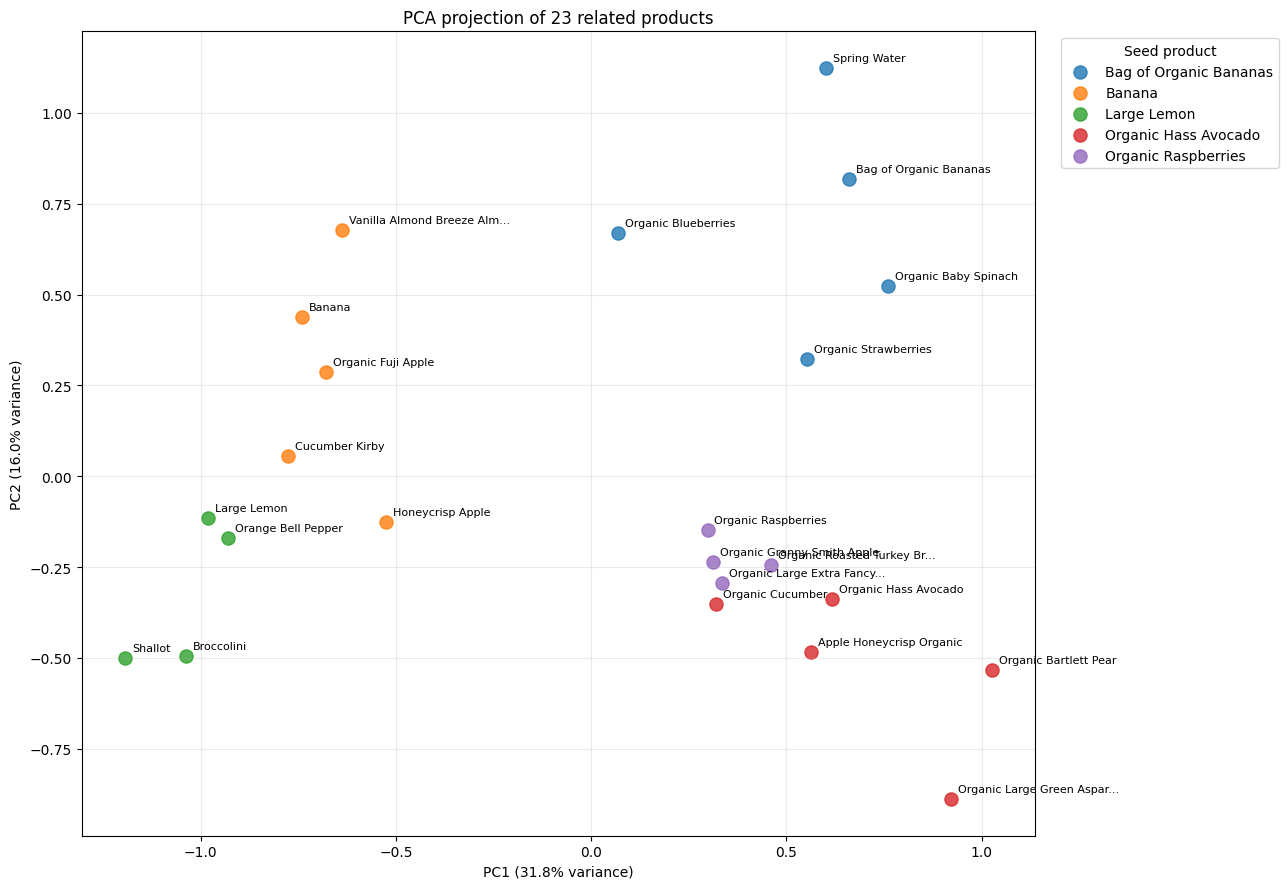

,product_name,seed_name,similarity_to_seed
0,Bag of Organic Bananas,Bag of Organic Bananas,1.000000
1,Organic Strawberries,Bag of Organic Bananas,0.869081
2,Organic Blueberries,Bag of Organic Bananas,0.853967
3,Organic Baby Spinach,Bag of Organic Bananas,0.839318
4,Spring Water,Bag of Organic Bananas,0.836521
5,Banana,Banana,1.000000
6,Organic Fuji Apple,Banana,0.880417
7,Cucumber Kirby,Banana,0.821444
8,Vanilla Almond Breeze Almond Milk,Banana,0.807199
9,Honeycrisp Apple,Banana,0.805050


In [13]:
# Pick 5 popular seed products and gather 4 nearest neighbours for each one
seed_product_ids = query_product_ids[:5]
products_per_seed = 4

selected_rows = []
seen_product_ids = set()

for seed_id in seed_product_ids:
    seed_token = str(seed_id)
    seed_name = product_names.get(seed_id, f"product_id={seed_id}")
    candidates = [(seed_token, 1.0)] + model.wv.most_similar(seed_token, topn=products_per_seed)
    
    for token, similarity in candidates:
        product_id = int(token)
        if product_id in seen_product_ids:
            continue
        seen_product_ids.add(product_id)
        selected_rows.append({
            "product_id": product_id,
            "product_name": product_names.get(product_id, f"product_id={product_id}"),
            "seed_name": seed_name,
            "similarity_to_seed": similarity,
        })

selected_products = pd.DataFrame(selected_rows)
selected_vectors = np.vstack([model.wv[str(pid)] for pid in selected_products["product_id"]])

# Project the selected product embeddings into 2 dimensions
pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords_2d = pca.fit_transform(selected_vectors)
selected_products[["pca_1", "pca_2"]] = coords_2d

plt.figure(figsize=(13, 9))
for seed_name, group in selected_products.groupby("seed_name"):
    plt.scatter(group["pca_1"], group["pca_2"], s=90, alpha=0.8, label=seed_name)

for _, row in selected_products.iterrows():
    label = row["product_name"]
    if len(label) > 28:
        label = label[:25] + "..."
    plt.annotate(label, (row["pca_1"], row["pca_2"]), xytext=(5, 5), textcoords="offset points", fontsize=8)

plt.title(f"PCA projection of {len(selected_products)} related products")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Seed product", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

selected_products[["product_name", "seed_name", "similarity_to_seed"]].head(10)
